In [32]:
# Importing Required libraries
import os
import re
import tarfile
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score
from difflib import SequenceMatcher
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

In [2]:
# Cloning dataset
!git clone https://github.com/bepnye/EBM-NLP.git

Cloning into 'EBM-NLP'...
remote: Enumerating objects: 200, done.
remote: Total 200 (delta 0), reused 0 (delta 0), pack-reused 200 (from 1)
Receiving objects: 100% (200/200), 83.47 MiB | 15.43 MiB/s, done.
Resolving deltas: 100% (82/82), done.


In [3]:
# Extracting first dataset
with tarfile.open("EBM-NLP/ebm_nlp_1_00.tar.gz", "r:gz") as tar:
    tar.extractall("ebm_nlp_1")

/tmp/ipykernel_12819/1507613752.py:3: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall("ebm_nlp_1")


In [4]:
# Extracting second dataset
with tarfile.open("EBM-NLP/ebm_nlp_2_00.tar.gz", "r:gz") as tar:
    tar.extractall("ebm_nlp_2")

/tmp/ipykernel_12819/3097051261.py:3: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall("ebm_nlp_2")


In [5]:
# Defining path
doc_path = "ebm_nlp_1/ebm_nlp_1_00/documents"
doc_path_2 = "ebm_nlp_2/ebm_nlp_2_00/documents"

In [6]:
# Initialising storage
documents = {}

In [7]:
# Reading all documents for both documents
for file in os.listdir(doc_path):
    with open(os.path.join(doc_path, file), "r", encoding="utf-8") as f:
        documents[file] = f.read()

for file in os.listdir(doc_path_2):
    with open(os.path.join(doc_path_2, file), "r", encoding="utf-8") as f:
        documents[file] = f.read()

In [8]:
# Loading datasets
dataset = []
for doc_id, text in documents.items():
    dataset.append({
        "abstract": text})

In [9]:
# Creating a dataframe
df = pd.DataFrame(dataset)
print("Total documents:", len(df))

Total documents: 19972


In [10]:
# Define a function to clean text
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s.]', ' ', text)
    text = " ".join(text.split())
    return text

In [11]:
# Apply the function
df["abstract"] = df["abstract"].apply(clean_text)

In [12]:
# Splitting Sentences
def split_sentences(text):
    return re.split(r'(?<=[.!?]) +', text)

In [13]:
# Creating a function for Ground Truth
def generate_ground_truth(text):
    sentences = split_sentences(text)

    population, intervention, outcome = [], [], []

    for sent in sentences:
        if any(w in sent for w in ["patients", "subjects", "participants", "adults"]):
            population.append(sent)

        if any(w in sent for w in ["treated", "received", "administered", "given"]):
            intervention.append(sent)

        if any(w in sent for w in ["improved", "reduction", "resulted", "decreased", "increased"]):
            outcome.append(sent)

    return " ".join(population), " ".join(intervention), " ".join(outcome)

In [14]:
# Apply the function for generating ground truth
df["population"], df["intervention"], df["outcome"] = zip(
    *df["abstract"].apply(generate_ground_truth))

In [15]:
# Checking output
df.head()

,abstract,population,intervention,outcome
0,beta adrenoceptor blockade and cardiovascular ...,seven healthy subjects immersed a hand in rand...,,the cold stress resulted in a significant incr...
1,phase ii multi institutional prospective rando...,phase ii multi institutional prospective rando...,,
2,brief report randomized test of the efficacy o...,,,
3,a single dose of gabapentin reduces acute pain...,a single dose of gabapentin reduces acute pain...,,pain severity decreased by 66 with gabapentin ...
4,prognostic factor analysis in patients with ad...,prognostic factor analysis in patients with ad...,prognostic factor analysis in patients with ad...,


In [16]:
# Check the information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19972 entries, 0 to 19971
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   abstract      19972 non-null  object
 1   population    19972 non-null  object
 2   intervention  19972 non-null  object
 3   outcome       19972 non-null  object
dtypes: object(4)
memory usage: 624.3+ KB


In [17]:
# Defining rule-based prediction
def rule_based_model(text):
    sentences = split_sentences(text)

    pop, inter, out = [], [], []

    for sent in sentences:
        if re.search(r"(patients|subjects|participants|adults)", sent):
            pop.append(sent)

        if re.search(r"(treated|received|administered|given|therapy|drug)", sent):
            inter.append(sent)

        if re.search(r"(improved|reduction|resulted|decreased|increased|effect)", sent):
            out.append(sent)

    return " ".join(pop), " ".join(inter), " ".join(out)

In [18]:
# Applying prediction
df["pred_population"], df["pred_intervention"], df["pred_outcome"] = zip(
    *df["abstract"].apply(rule_based_model))

In [19]:
# Defining a baseline model function
def baseline_model(text):
    sentences = split_sentences(text)

    pop, inter, out = "", "", ""

    for sent in sentences:
        if "patients" in sent or "adults" in sent:
            pop = sent
        if "treated" in sent or "received" in sent:
            inter = sent
        if "improved" in sent or "reduction" in sent:
            out = sent

    return pop, inter, out

In [20]:
# Applying the function for baseline model
df["base_population"], df["base_intervention"], df["base_outcome"] = zip(
    *df["abstract"].apply(baseline_model))

In [21]:
# Defining a similarity function
def similarity(a, b):
    return SequenceMatcher(None, a, b).ratio()

In [22]:
# Defining an Evaluation function
def evaluate(true, pred, threshold=0.5):
    matches = []
    total = 0

    for t, p in zip(true, pred):
        if t.strip() == "":
            continue

        total += 1
        sim = similarity(t, p)
        matches.append(1 if sim >= threshold else 0)

    if total == 0:
        return 0, 0, 0

    precision = sum(matches) / len(matches)
    recall = sum(matches) / total
    f1 = 2 * precision * recall / (precision + recall + 1e-8)

    return precision, recall, f1

In [23]:
# Evaluating Rule-based
rp_p, rr_p, rf_p = evaluate(df["population"], df["pred_population"])
rp_i, rr_i, rf_i = evaluate(df["intervention"], df["pred_intervention"])
rp_o, rr_o, rf_o = evaluate(df["outcome"], df["pred_outcome"])

In [24]:
# Evaluating Baseline
bp_p, br_p, bf_p = evaluate(df["population"], df["base_population"])
bp_i, br_i, bf_i = evaluate(df["intervention"], df["base_intervention"])
bp_o, br_o, bf_o = evaluate(df["outcome"], df["base_outcome"])

In [25]:
# Print Rule Based Model Results
print("Population:", rp_p, rr_p, rf_p)
print("Intervention:", rp_i, rr_i, rf_i)
print("Outcome:", rp_o, rr_o, rf_o)

Population: 1.0 1.0 0.999999995
Intervention: 0.8507194244604317 0.8507194244604317 0.8507194194604317
Outcome: 0.7669887278582931 0.7669887278582931 0.7669887228582931


In [26]:
# Print Baseline Model Results
print("Population:", bp_p, br_p, bf_p)
print("Intervention:", bp_i, br_i, bf_i)
print("Outcome:", bp_o, br_o, bf_o)

Population: 0.2794790566701866 0.2794790566701866 0.27947905167018666
Intervention: 0.5783872901678657 0.5783872901678657 0.5783872851678658
Outcome: 0.3972624798711755 0.3972624798711755 0.3972624748711756


In [27]:
# Creating a dataframe for Comparison
results = pd.DataFrame({
    "Field": ["Population", "Intervention", "Outcome"],
    "Rule-Based F1": [rf_p, rf_i, rf_o],
    "Baseline F1": [bf_p, bf_i, bf_o]
})

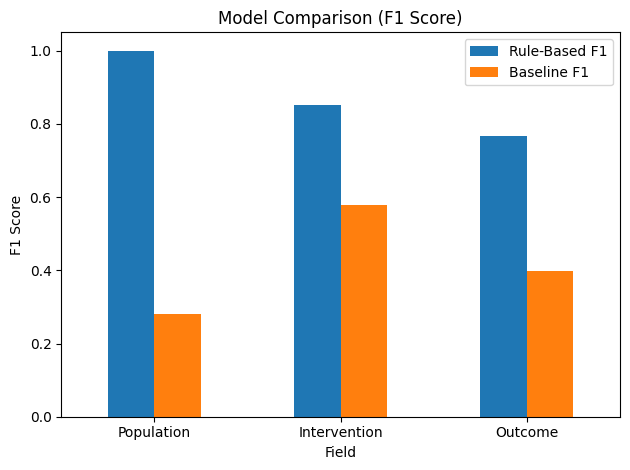

In [28]:
# Visualising the model comparison
results.set_index("Field").plot(kind="bar")
plt.title("Model Comparison (F1 Score)")
plt.ylabel("F1 Score")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [29]:
# extracting failure cases
errors = df[df["population"] != df["pred_population"]]

In [30]:
# Print Sample Errors
print(errors[["abstract", "population", "pred_population"]].head())

Empty DataFrame
Columns: [abstract, population, pred_population]
Index: []


In [33]:
# Extracting sentences from all abstracts
all_sentences = []

for text in df["abstract"]:
    all_sentences.extend(split_sentences(text))

In [34]:
# Removing empty sentences
all_sentences = [s for s in all_sentences if len(s.strip()) > 5]

In [35]:
# Converting text to vectors
vectorizer = TfidfVectorizer(max_features=1000)
X = vectorizer.fit_transform(all_sentences)

In [36]:
# Applying KMeans clustering
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X)

In [37]:
# Creating DataFrame
cluster_df = pd.DataFrame({
    "sentence": all_sentences,
    "cluster": clusters
})

In [38]:
# Viewing cluster samples
for i in range(3):
    print(f"\n Cluster {i} ")
    print(cluster_df[cluster_df["cluster"] == i]["sentence"].head(5))


 Cluster 0 
2    the cold stress resulted in a significant incr...
3    beta adrenoceptor blockade did not affect the ...
4    the changes induced by the cold stress in the ...
5    the highest rate pressure product during the c...
7    in the recovery phase the cardiovascular varia...
Name: sentence, dtype: object

 Cluster 1 
109749                            nn in jj nn in jj nn nn .
109750                        dt jj nn nn vbg jj nn cc nn .
109751    dt nn in dt nns in jj nn vbz in jj nn in jj nn...
109752    nn in dt vbg nn in jj nn nn vbz dt jj nn in dt...
109753    nnp nnp vbz rb vbn vbn rb to vb jj nn nn in pr...
Name: sentence, dtype: object

 Cluster 2 
0     beta adrenoceptor blockade and cardiovascular ...
1     seven healthy subjects immersed a hand in rand...
6     this was well below the pain threshold value o...
8     phase ii multi institutional prospective rando...
10    this is the first randomised phase ii trial to...
Name: sentence, dtype: object


In [39]:
# Coverage calculation
def coverage(pred):
    return sum([1 for p in pred if p.strip() != ""]) / len(pred)

print("Population:", coverage(df["pred_population"]))
print("Intervention:", coverage(df["pred_intervention"]))
print("Outcome:", coverage(df["pred_outcome"]))

Population: 0.5689965952333267
Intervention: 0.4401161626276788
Outcome: 0.553224514320048


In [41]:
# find all interventions with "insulin"
query_results = df[df["pred_intervention"].str.contains("insulin", na=False)]
query_results[["abstract", "pred_intervention"]].head()

,abstract,pred_intervention
43,cholesterol lowering therapy may retard the pr...,cholesterol lowering therapy may retard the pr...
159,significant differential effects of omega 3 fa...,fifty patients in each group were given placeb...
282,resource utilization and costs of care in the ...,research design and methods the resources used...
315,pulsatile insulin delivery is more efficient t...,in all experiments 5 g arginine were given iv ...
861,impact of empagliflozin added on to basal insu...,aims to investigate the efficacy and tolerabil...
